In [4]:
import sys

MODULES_PATH = "../modules"
if MODULES_PATH not in sys.path:
    sys.path.append(MODULES_PATH)

from assets_etl import *
from tweets_etl import *
from utils import *
    
from bsts import BSTSForCausalInferenceWrapper

import pandas as pd
import datetime as dt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
ticker2permno = {
    "TSLA": 93436
}

####  LOAD AND PROCESS THE TWEETS OF INTEREST

In [8]:
tweets = process_for_bsts(pd.read_csv("../data/twitter/farouk_tesla_tweets.csv"))
tweets[["text", "id"]]

,text,id
0,You can now buy a Tesla with Bitcoin,1374617643446063105
1,u can’t sell houses u don’t own u can’t sell c...,1354890601649610753
2,Plaid Model S ships next month https://t.co/HF...,1354618504532684802
3,Tesla has 💎 🙌,1395027147161489412
4,Tesla is restarting production today against A...,1259945593805221891
5,@POTUS Or you can just buy a Tesla,1599269250375380992
6,"View from SpaceX Launch Control. Apparently, t...",960992715579125760
7,This is my finest work – please add to gravest...,1626703667591270400
8,(from making fun of Gates for shorting Tesla w...,1518234561150427141
9,Time to tell the story of Tesla &amp; SpaceX,1358176884312272898


In [18]:
limit_date = dt.datetime(2022, 12, 30)

start_date = (tweets.date.min() - pd.DateOffset(60)).strftime("%Y-%m-%d")
end_date   = min((tweets.date.max() + pd.DateOffset(31)), limit_date).strftime("%Y-%m-%d")

#### DOWNLOAD THE DATA NECESSARY FOR THE ANALYSIS

In [19]:
# wrds_loader = WRDSLoader(username="farouk_b")
# wrds_loader.download_stock_data(ticker2permno, from_=start_date, to=end_date, save_to="../data/stocks/", close_conn=False)
# wrds_loader.close()

### LOAD AND PREPROCESS THE DATA

In [20]:
stocks = {}
stocks["TSLA"] = preproc_tsla_for_bsts(pd.read_csv("../data/stocks/TSLA_2017_2023.csv"))
ff_df = preproc_ff3_for_bsts(pd.read_csv("../data/factors/ff3.csv"))

### BSTS ANALYSIS

In [24]:
pre_effect_lag_window  = 21 # days
post_effect_lag_window = 7  # days

models = {}
not_analyzable_tweets = []

for ticker, stock_df in stocks.items():
    data = prepare_for_bsts(stock_df, ff_df, start_date, end_date)
    prepared_data = data.drop(columns=["date"]).astype(float)
    
    for _, tweet in tweets.iterrows():
        models[tweet.id] = {}
    
        effect_lag = arg_nearest_after(tweet.date, data.date)
        if effect_lag is None:
            not_analyzable_tweets.append(tweet.id)
            continue
        effect_lag = int(effect_lag)
        bsts_model = BSTSForCausalInferenceWrapper(data=prepared_data)
        bsts_model.fit(effect_lag, pre_effect_lag_window, post_effect_lag_window)
        
        models[tweet.id][ticker] = bsts_model

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.72449D-01    |proj g|=  3.47147D-01

At iterate    5    f=  8.90151D-01    |proj g|=  1.82156D-02

At iterate   10    f=  8.89628D-01    |proj g|=  1.27340D-03

At iterate   15    f=  8.89618D-01    |proj g|=  7.13812D-03

At iterate   20    f=  8.89506D-01    |proj g|=  5.92544D-03

At iterate   25    f=  8.89497D-01    |proj g|=  1.96769D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6     26     42      1     0     0   

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.25192D-01    |proj g|=  3.21817D-01

At iterate    5    f=  9.00497D-01    |proj g|=  2.38790D-03

At iterate   10    f=  9.00492D-01    |proj g|=  2.23194D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6     10     19      1     0     0   2.232D-05   9.005D-01
  F =  0.90049185367547679     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.10751D+00    |proj g|=  2.82678D-01

At iterate    5    f=  1.03030D+00    |proj g|=  7.14764D-02

At iterate   10    f=  1.01985D+00    |proj g|=  7.56918D-03

At iterate   15    f=  1.01977D+00    |proj g|=  6.90821D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6     18     22      1     0     0   9.608D-06   1.020D+00
  F =   1.0197679710533887     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
RUNNING 

 This problem is unconstrained.
 This problem is unconstrained.


                                 Average        Cumulative
Actual                                 0                 0
Predicted                              0                 0
95% CI                            [0, 0]            [0, 0]
                                                          
Absolute Effect                        0                 0
95% CI                            [0, 0]            [0, 0]
                                                          
Relative Effect                   -99.5%            -99.5%
95% CI                  [48.1%, -247.1%]  [48.1%, -247.1%]
                                                          
P-value                             9.2%                  
Prob. of Causal Effect             90.8%                  
None


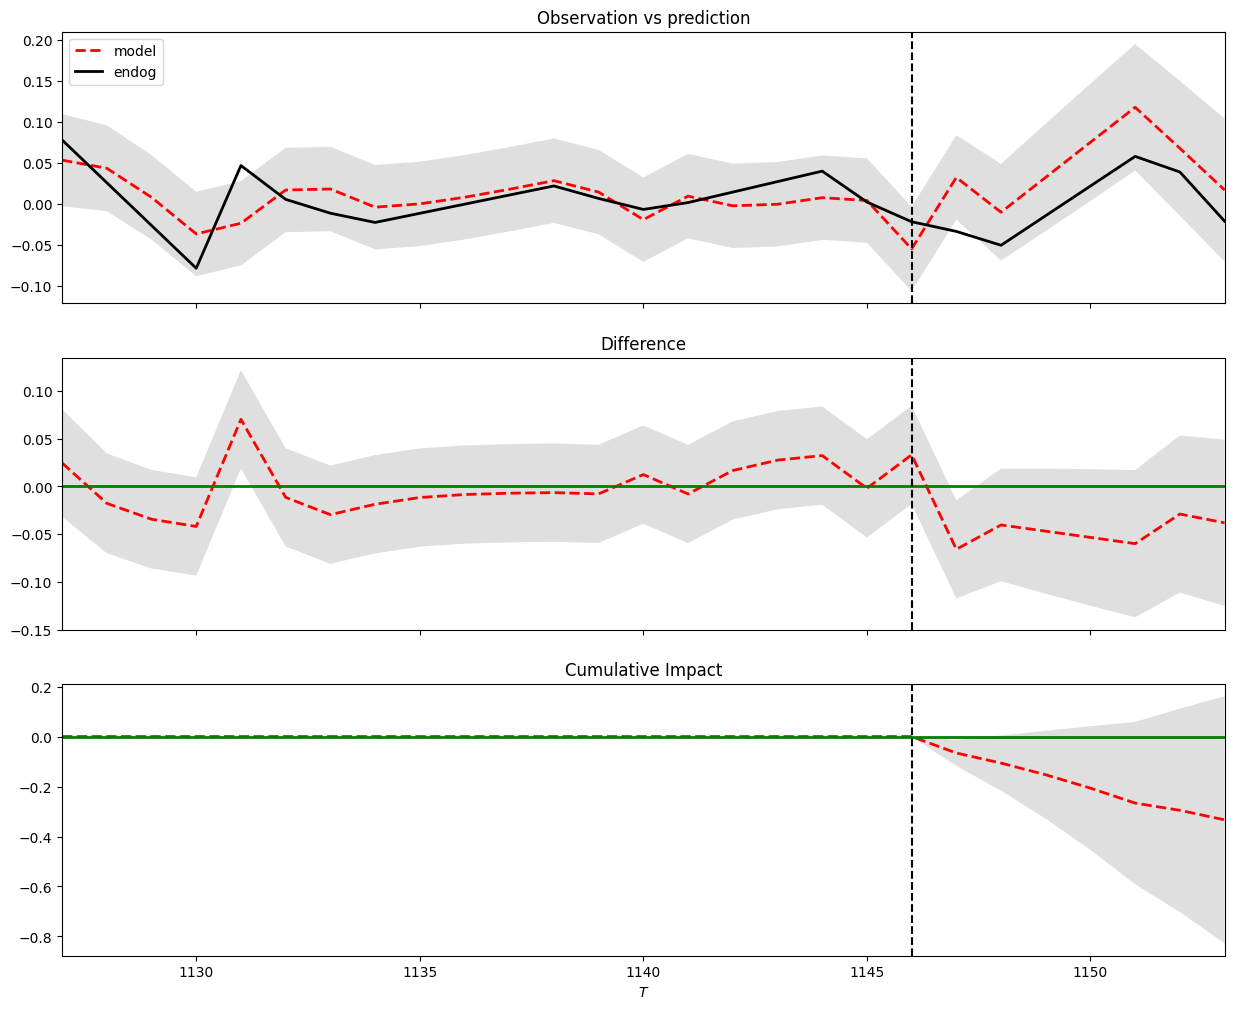

In [25]:
ticker = "TSLA"
tweet_id = 1354618504532684802
models[tweet_id][ticker].summary()
models[tweet_id][ticker].plot()